<a href="https://colab.research.google.com/github/Shaurya-XD/diabetic_retinopathy/blob/main/pleaseWorkAMEN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Diabetic Retinopathy Screening — End-to-End Colab v3

This notebook is a complete screening prototype built around three goals:

1. **Grade diabetic retinopathy (DR)** from APTOS fundus photographs with EfficientNetB0.
2. **Localize DR lesions** from IDRiD with a pretrained-encoder U-Net.
3. **Explain and validate** predictions using Grad-CAM, calibrated referral probabilities, a held-out APTOS test set, and Messidor-2 external validation when valid labels are available.

## Why the segmentation design is different in v3

The previous five-channel segmentation branch was too difficult for the small, extremely imbalanced IDRiD segmentation set. Tiny lesion channels encouraged background collapse.

This version predicts a **single DR-lesion union mask**:

- microaneurysms
- hemorrhages
- hard exudates
- soft exudates

The optic disc is deliberately excluded because it is a normal anatomical structure, not a DR lesion.

The segmentation model now uses:

- ImageNet-pretrained **MobileNetV2 encoder**
- U-Net-style decoder with skip connections
- paired image/mask augmentation
- focal + Tversky loss for severe foreground/background imbalance
- two-stage training (decoder first, then conservative fine-tuning)
- validation-tuned segmentation probability threshold
- finite `tf.data` datasets with known cardinality (no generator exhaustion warning)

## Important methodological safeguards

- APTOS is split into **train / validation / final held-out test**.
- Validation data is used for early stopping, probability calibration, and threshold tuning.
- The final APTOS test set is not used during model development.
- EfficientNetB0 receives float image pixels in the expected **0–255** range.
- The same spatial crop is applied to IDRiD fundus images and masks.
- If data matching or masks are invalid, the notebook raises an error instead of silently training on bad labels.
- Reported performance comes from actual run outputs; the notebook does not fabricate target metrics.

> This is a screening / decision-support prototype, not a clinical diagnostic device.


In [1]:
# Cell 2 — Install lightweight dependencies only
# TensorFlow/Keras, NumPy, Pandas, OpenCV, SciPy and scikit-learn are normally
# already present in Google Colab. Reinstalling them can create version conflicts.

!pip -q install reportlab rarfile psutil


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.6 MB/s eta 0:00:00


In [2]:
# Cell 3 — Imports, reproducibility and hardware
import os
import sys
import json
import math
import random
import shutil
import zipfile
import tarfile
import subprocess
import warnings
from pathlib import Path
from collections import Counter

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import psutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from scipy.optimize import minimize_scalar

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score,
    log_loss,
    ConfusionMatrixDisplay,
)

tf.random.set_seed(SEED)

GPUS = tf.config.list_physical_devices("GPU")
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
print("Python     :", sys.version.split()[0])
print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("OpenCV     :", cv2.__version__)
print("GPU        :", GPUS if GPUS else "Not detected")


ENVIRONMENT
Python     : 3.13.15
TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.1.3
Pandas     : 2.2.3
OpenCV     : 4.14.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 4 — Mount Drive and configure project paths
from google.colab import drive

drive.mount("/content/drive")

# Change only this line if your SIH folder is elsewhere.
DRIVE_ROOT = Path("/content/drive/MyDrive/sih")

WORK_ROOT = Path("/content/dr_work")
OUTPUT_ROOT = DRIVE_ROOT / "outputs_v3"

if not DRIVE_ROOT.exists():
    raise FileNotFoundError(
        f"Project folder not found: {DRIVE_ROOT}\n"
        "Expected Google Drive > My Drive > sih"
    )

WORK_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Project folder :", DRIVE_ROOT)
print("Local workspace:", WORK_ROOT)
print("Output folder  :", OUTPUT_ROOT)

print("\nTop-level files:")
for p in sorted(DRIVE_ROOT.iterdir()):
    print(" -", p.name)


Mounted at /content/drive
Project folder : /content/drive/MyDrive/sih
Local workspace: /content/dr_work
Output folder  : /content/drive/MyDrive/sih/outputs_v3

Top-level files:
 - A. Segmentation.zip
 - B. Disease Grading.zip
 - C. Localization.zip
 - IMAGES.zip.001
 - IMAGES.zip.002
 - IMAGES.zip.003
 - IMAGES.zip.004
 - aptos2019-blindness-detection.zip
 - messidor-2.csv
 - outputs
 - outputs_corrected
 - outputs_v3


In [4]:
# Cell 5 — Resource-aware configuration
RAM_GB = psutil.virtual_memory().total / 1e9
GPU_AVAILABLE = bool(GPUS)

# Classification benefits from more retinal detail than 224x224.
CLS_SIZE = (300, 300) if GPU_AVAILABLE else (224, 224)
CLS_BATCH = 12 if GPU_AVAILABLE else 4

# Binary lesion segmentation is trained at a somewhat larger resolution.
SEG_SIZE = (384, 384) if GPU_AVAILABLE else (256, 256)
SEG_BATCH = 4 if GPU_AVAILABLE else 2

HEAD_EPOCHS = 10 if GPU_AVAILABLE else 3
FINE_EPOCHS = 14 if GPU_AVAILABLE else 3

SEG_STAGE1_EPOCHS = 15 if GPU_AVAILABLE else 4
SEG_STAGE2_EPOCHS = 20 if GPU_AVAILABLE else 4

CLS_FINE_TUNE_LAYERS = 35
SEG_FINE_TUNE_LAYERS = 35

if RAM_GB < 13:
    CLS_BATCH = min(CLS_BATCH, 8)
    SEG_BATCH = min(SEG_BATCH, 2)

AUTOTUNE = tf.data.AUTOTUNE

CONFIG = {
    "ram_gb": round(RAM_GB, 1),
    "gpu": GPU_AVAILABLE,
    "cls_size": CLS_SIZE,
    "cls_batch": CLS_BATCH,
    "seg_size": SEG_SIZE,
    "seg_batch": SEG_BATCH,
    "head_epochs": HEAD_EPOCHS,
    "fine_epochs": FINE_EPOCHS,
    "seg_stage1_epochs": SEG_STAGE1_EPOCHS,
    "seg_stage2_epochs": SEG_STAGE2_EPOCHS,
}

print(json.dumps(CONFIG, indent=2))


{
  "ram_gb": 13.6,
  "gpu": true,
  "cls_size": [
    300,
    300
  ],
  "cls_batch": 12,
  "seg_size": [
    384,
    384
  ],
  "seg_batch": 4,
  "head_epochs": 10,
  "fine_epochs": 14,
  "seg_stage1_epochs": 15,
  "seg_stage2_epochs": 20
}


In [5]:
# Cell 6 — File/archive helpers
IMG_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

def copy_to_local(src, dst_dir=WORK_ROOT):
    src = Path(src)
    if src.is_dir():
        return src

    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name

    if dst.exists() and dst.stat().st_size == src.stat().st_size:
        print("Already copied:", dst.name)
        return dst

    total = src.stat().st_size
    with open(src, "rb") as fi, open(dst, "wb") as fo, tqdm(
        total=total, unit="B", unit_scale=True, desc=f"Copy {src.name}"
    ) as bar:
        while True:
            chunk = fi.read(16 * 1024 * 1024)
            if not chunk:
                break
            fo.write(chunk)
            bar.update(len(chunk))

    return dst

def extract_archive(archive_path, out_dir):
    archive_path = Path(archive_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    name = archive_path.name.lower()
    suffix = archive_path.suffix.lower()

    try:
        if suffix == ".zip":
            with zipfile.ZipFile(archive_path) as z:
                bad = z.testzip()
                if bad:
                    raise zipfile.BadZipFile(f"CRC failure: {bad}")
                z.extractall(out_dir)

        elif suffix == ".rar":
            import rarfile
            with rarfile.RarFile(archive_path) as r:
                r.extractall(out_dir)

        elif suffix in {".tar", ".gz", ".tgz", ".bz2", ".xz"} or ".tar." in name:
            with tarfile.open(archive_path) as t:
                t.extractall(out_dir)

        else:
            raise ValueError(f"Unsupported archive format: {archive_path}")

        return True

    except Exception as e:
        print("Extraction failed:", type(e).__name__, e)
        return False

def resolve_or_extract(prefix, local_name, required=True):
    matches = sorted(DRIVE_ROOT.glob(prefix + "*"))

    if not matches:
        if required:
            raise FileNotFoundError(
                f"No file/folder beginning with '{prefix}' under {DRIVE_ROOT}"
            )
        print(f"WARNING: '{prefix}*' not found.")
        return None

    src = matches[0]

    if src.is_dir():
        print("Using directory:", src)
        return src

    local_archive = copy_to_local(src)
    out = WORK_ROOT / local_name

    if out.exists() and any(out.iterdir()):
        print("Using previously extracted:", out)
        return out

    if not extract_archive(local_archive, out):
        if required:
            raise RuntimeError(f"Could not extract: {src}")
        return None

    return out

def index_images(root):
    rows = []
    if root is None:
        return pd.DataFrame(columns=["filepath", "filename", "stem"])

    for p in Path(root).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            rows.append({
                "filepath": str(p),
                "filename": p.name,
                "stem": p.stem,
            })

    return pd.DataFrame(rows)

def find_col(df, candidates):
    low = {str(c).strip().lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]

    for col in df.columns:
        cl = str(col).strip().lower()
        if any(c.lower() in cl for c in candidates):
            return col

    return None

def print_tree(root, n=40):
    if root is None:
        return
    files = [p for p in Path(root).rglob("*") if p.is_file()]
    print(f"{len(files)} files under {root}")
    for p in files[:n]:
        print(" -", p.relative_to(root))
    if len(files) > n:
        print(f"... {len(files)-n} more")


In [6]:
# Cell 7 — Resolve APTOS 2019
aptos_matches = sorted(DRIVE_ROOT.glob("aptos2019-blindness-detection*"))

if not aptos_matches:
    raise FileNotFoundError(
        "APTOS 2019 archive/folder was not found under MyDrive/sih."
    )

aptos_src = aptos_matches[0]

if aptos_src.is_dir():
    aptos_root = aptos_src
else:
    local = copy_to_local(aptos_src)
    aptos_root = WORK_ROOT / "APTOS2019"
    if not aptos_root.exists() or not any(aptos_root.iterdir()):
        if not extract_archive(local, aptos_root):
            raise RuntimeError("APTOS extraction failed.")

print("APTOS root:", aptos_root)
print_tree(aptos_root, 30)


Copy aptos2019-blindness-detection.zip:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

APTOS root: /content/dr_work/APTOS2019
5593 files under /content/dr_work/APTOS2019
 - sample_submission.csv
 - test.csv
 - train.csv
 - train_images/80dbeb0fdc75.png
 - train_images/247ac63e5510.png
 - train_images/3c28fd846b43.png
 - train_images/17e6116b89b3.png
 - train_images/b8dab47a260e.png
 - train_images/4d9fc85a8259.png
 - train_images/f549294e12e1.png
 - train_images/3b0190bbe615.png
 - train_images/50ddd7d976df.png
 - train_images/8b568d47a1fd.png
 - train_images/875d2ffcbf47.png
 - train_images/7aabd768abff.png
 - train_images/1bb0ddfe753a.png
 - train_images/e3cd96cb094c.png
 - train_images/c68dfa021d62.png
 - train_images/1864d3411143.png
 - train_images/b553e7909535.png
 - train_images/d88c4843aec3.png
 - train_images/28dc010a0780.png
 - train_images/3206171db5be.png
 - train_images/26fc2358a38d.png
 - train_images/b9fe7da14a32.png
 - train_images/0bf37ca3156a.png
 - train_images/8acdf12f412a.png
 - train_images/342edf9b889d.png
 - train_images/e12f9f19d1be.png
 - train_

In [7]:
# Cell 8 — Resolve IDRiD segmentation data
idrid_seg_root = resolve_or_extract(
    "A. Segmentation",
    "IDRiD_Segmentation",
    required=True
)

print("IDRiD segmentation root:", idrid_seg_root)
print_tree(idrid_seg_root, 40)


Copy A. Segmentation.zip:   0%|          | 0.00/584M [00:00<?, ?B/s]

IDRiD segmentation root: /content/dr_work/IDRiD_Segmentation
446 files under /content/dr_work/IDRiD_Segmentation
 - A. Segmentation/CC-BY-4.0.txt
 - A. Segmentation/LICENSE.txt
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_06.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_04.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_07.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_30.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_46.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_40.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_20.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_26.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_45.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_18.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_49.jpg
 - A. Segmentation/1. Original Images/a. Training Set/IDRiD_11.jpg
 - A. Segmentation/

In [8]:
# Cell 9 — Resolve Messidor-2 images if available
def resolve_messidor():
    # Already extracted folder?
    folder_candidates = [
        p for p in DRIVE_ROOT.glob("*Messidor*")
        if p.is_dir()
    ]
    if folder_candidates:
        print("Using Messidor directory:", folder_candidates[0])
        return folder_candidates[0]

    parts = [DRIVE_ROOT / f"IMAGES.zip.{i:03d}" for i in range(1, 5)]

    if not all(p.exists() for p in parts):
        print("Messidor-2 split archive not fully present; external validation may be skipped.")
        return None

    local_parts = [copy_to_local(p) for p in parts]
    combined = WORK_ROOT / "MESSIDOR_IMAGES.zip"
    out = WORK_ROOT / "Messidor2"
    marker = out / ".complete"

    if marker.exists():
        return out

    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True, exist_ok=True)

    # First try direct binary concatenation.
    try:
        with open(combined, "wb") as fo:
            for part in local_parts:
                with open(part, "rb") as fi:
                    shutil.copyfileobj(fi, fo, 16 * 1024 * 1024)

        with zipfile.ZipFile(combined) as z:
            bad = z.testzip()
            if bad:
                raise zipfile.BadZipFile(bad)
            z.extractall(out)

        marker.touch()
        print("Messidor extracted by concatenating split parts.")
        return out

    except Exception as e:
        print("Direct split-ZIP extraction failed:", e)

    # Fallback to 7-Zip.
    try:
        subprocess.run(["apt-get", "update", "-qq"], check=True)
        subprocess.run(["apt-get", "install", "-y", "-qq", "p7zip-full"], check=True)

        result = subprocess.run(
            ["7z", "x", str(local_parts[0]), f"-o{out}", "-y"],
            capture_output=True,
            text=True,
        )

        if result.returncode != 0:
            raise RuntimeError(result.stderr[-2000:])

        marker.touch()
        print("Messidor extracted with 7-Zip.")
        return out

    except Exception as e:
        print("WARNING: Messidor extraction failed:", e)
        return None

messidor_root = resolve_messidor()
print("Messidor root:", messidor_root)


Copy IMAGES.zip.001:   0%|          | 0.00/734M [00:00<?, ?B/s]

Copy IMAGES.zip.002:   0%|          | 0.00/734M [00:00<?, ?B/s]

Copy IMAGES.zip.003:   0%|          | 0.00/734M [00:00<?, ?B/s]

Copy IMAGES.zip.004:   0%|          | 0.00/253M [00:00<?, ?B/s]

Messidor extracted by concatenating split parts.
Messidor root: /content/dr_work/Messidor2


In [9]:
# Cell 10 — Build APTOS manifest and validate labels
aptos_csv = next(iter(Path(aptos_root).rglob("train.csv")), None)

if aptos_csv is None:
    raise FileNotFoundError("APTOS train.csv not found.")

aptos_images = index_images(aptos_root)
aptos_labels = pd.read_csv(aptos_csv)

id_col = find_col(
    aptos_labels,
    ["id_code", "image_id", "image", "filename"]
)
target_col = find_col(
    aptos_labels,
    ["diagnosis", "dr_grade", "grade", "label"]
)

if id_col is None or target_col is None:
    raise ValueError(
        f"Could not identify APTOS image/target columns: {aptos_labels.columns.tolist()}"
    )

image_map = {}
for _, r in aptos_images.iterrows():
    image_map.setdefault(r["stem"].lower(), r["filepath"])

aptos_df = aptos_labels.copy()
aptos_df["filepath"] = aptos_df[id_col].astype(str).map(
    lambda x: image_map.get(Path(x).stem.lower())
)
aptos_df["label"] = pd.to_numeric(
    aptos_df[target_col],
    errors="coerce"
)

aptos_df = aptos_df.dropna(subset=["filepath", "label"]).copy()
aptos_df["label"] = aptos_df["label"].astype(int)
aptos_df = aptos_df[aptos_df["label"].between(0, 4)].reset_index(drop=True)

expected = {0, 1, 2, 3, 4}
found = set(aptos_df["label"].unique())

if found != expected:
    raise ValueError(f"Expected labels {expected}; found {found}")

if len(aptos_df) < 1000:
    raise ValueError(
        f"Only {len(aptos_df)} APTOS rows were matched. "
        "This suggests the archive/CSV mapping is incomplete."
    )

print("Usable APTOS rows:", len(aptos_df))
print("\nClass distribution:")
print(aptos_df["label"].value_counts().sort_index())

display(aptos_df[[id_col, "label", "filepath"]].head())


Usable APTOS rows: 3662

Class distribution:
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


,id_code,label,filepath
0,000c1434d8d7,2,/content/dr_work/APTOS2019/train_images/000c14...
1,001639a390f0,4,/content/dr_work/APTOS2019/train_images/001639...
2,0024cdab0c1e,1,/content/dr_work/APTOS2019/train_images/0024cd...
3,002c21358ce6,0,/content/dr_work/APTOS2019/train_images/002c21...
4,005b95c28852,0,/content/dr_work/APTOS2019/train_images/005b95...


In [10]:
# Cell 11 — Fundus crop and quality assessment
def fundus_bbox_bgr(img, threshold=10):
    if img is None or img.size == 0:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    coords = np.argwhere(gray > threshold)

    if len(coords) == 0:
        h, w = gray.shape
        return 0, h, 0, w

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return int(y0), int(y1), int(x0), int(x1)

def crop_fundus_bgr(img):
    bbox = fundus_bbox_bgr(img)
    if bbox is None:
        return img

    y0, y1, x0, x1 = bbox
    return img[y0:y1, x0:x1]

def assess_quality(img):
    if img is None or img.size == 0:
        return {"ok": False, "reason": "unreadable"}

    crop = crop_fundus_bgr(img)

    if crop is None or crop.size == 0:
        return {"ok": False, "reason": "empty_crop"}

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    lap = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    mean = float(gray.mean())
    std = float(gray.std())
    bright = float((gray > 245).mean())

    reasons = []
    if lap < 12:
        reasons.append("blur")
    if std < 18:
        reasons.append("low_contrast")
    if mean < 15 or mean > 245:
        reasons.append("extreme_exposure")
    if bright > 0.60:
        reasons.append("overexposed")

    return {
        "ok": len(reasons) == 0,
        "reason": ",".join(reasons) if reasons else "ok",
        "laplacian_var": lap,
        "mean": mean,
        "std": std,
        "bright_frac": bright,
    }

quality_rows = []

for fp in tqdm(aptos_df["filepath"], desc="APTOS quality scan"):
    r = assess_quality(cv2.imread(fp))
    r["filepath"] = fp
    quality_rows.append(r)

quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(OUTPUT_ROOT / "aptos_quality.csv", index=False)

aptos_df = aptos_df.merge(quality_df, on="filepath", how="left", validate="one_to_one")

# Only truly unreadable/empty data is removed.
bad_reasons = {"unreadable", "empty_crop"}
usable_mask = ~aptos_df["reason"].isin(bad_reasons)
aptos_df = aptos_df[usable_mask].reset_index(drop=True)

print("Rows after unreadable-image filtering:", len(aptos_df))
print("\nQuality flags:")
print(aptos_df["reason"].value_counts().head(12))


APTOS quality scan:   0%|          | 0/3662 [00:00<?, ?it/s]

Rows after unreadable-image filtering: 3662

Quality flags:
reason
ok                   2467
blur                 1125
blur,low_contrast      44
low_contrast           26
Name: count, dtype: int64


In [11]:
# Cell 12 — Stratified APTOS train / validation / final test split
# 70% train / 15% validation / 15% held-out test.

train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.30,
    stratify=aptos_df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("FINAL TEST", test_df),
]:
    print(f"\n{name}: {len(df)}")
    print(df["label"].value_counts().sort_index())



TRAIN: 2563
label
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

VALIDATION: 549
label
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

FINAL TEST: 550
label
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


In [12]:
# Cell 13 — EfficientNet classifier input pipeline
# Keras EfficientNet contains its own rescaling layer and expects float pixels
# in approximately [0,255]. Do NOT divide the classifier input by 255.

def tf_crop_black_border(img, threshold=10.0):
    gray = tf.reduce_mean(img, axis=-1)
    coords = tf.where(gray > threshold)

    def do_crop():
        y0 = tf.reduce_min(coords[:, 0])
        y1 = tf.reduce_max(coords[:, 0]) + 1
        x0 = tf.reduce_min(coords[:, 1])
        x1 = tf.reduce_max(coords[:, 1]) + 1
        return img[y0:y1, x0:x1, :]

    return tf.cond(
        tf.shape(coords)[0] > 0,
        do_crop,
        lambda: img
    )

def decode_classifier_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False
    )
    img.set_shape([None, None, 3])

    img = tf.cast(img, tf.float32)
    img = tf_crop_black_border(img)

    img = tf.image.resize(
        img,
        CLS_SIZE,
        method="bilinear",
        antialias=True
    )

    return tf.clip_by_value(img, 0.0, 255.0)

classifier_augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05, fill_mode="reflect"),
        layers.RandomZoom(0.08, fill_mode="reflect"),
        layers.RandomContrast(0.10),
    ],
    name="classifier_augmentation",
)

def make_cls_ds(df, training=False, batch_size=CLS_BATCH):
    paths = df["filepath"].astype(str).values
    labels = df["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    def load(path, label):
        img = decode_classifier_image(path)

        if training:
            img = classifier_augment(img, training=True)
            img = tf.clip_by_value(img, 0.0, 255.0)

        return img, label

    ds = ds.map(load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_cls_ds(train_df, training=True)
val_ds = make_cls_ds(val_df, training=False)
test_ds = make_cls_ds(test_df, training=False)

classes = np.sort(train_df["label"].unique())
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)
class_weight = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}

x_check, y_check = next(iter(val_ds))

print("Class weights:", class_weight)
print(
    "Classifier input min/max:",
    float(tf.reduce_min(x_check)),
    float(tf.reduce_max(x_check))
)

if float(tf.reduce_max(x_check)) <= 1.5:
    raise RuntimeError(
        "Classifier images appear normalized to [0,1]. "
        "EfficientNetB0 in this notebook expects [0,255]."
    )


Class weights: {0: 0.4058590657165479, 1: 1.9791505791505792, 2: 0.7333333333333333, 3: 3.797037037037037, 4: 2.476328502415459}
Classifier input min/max: 0.0 255.0


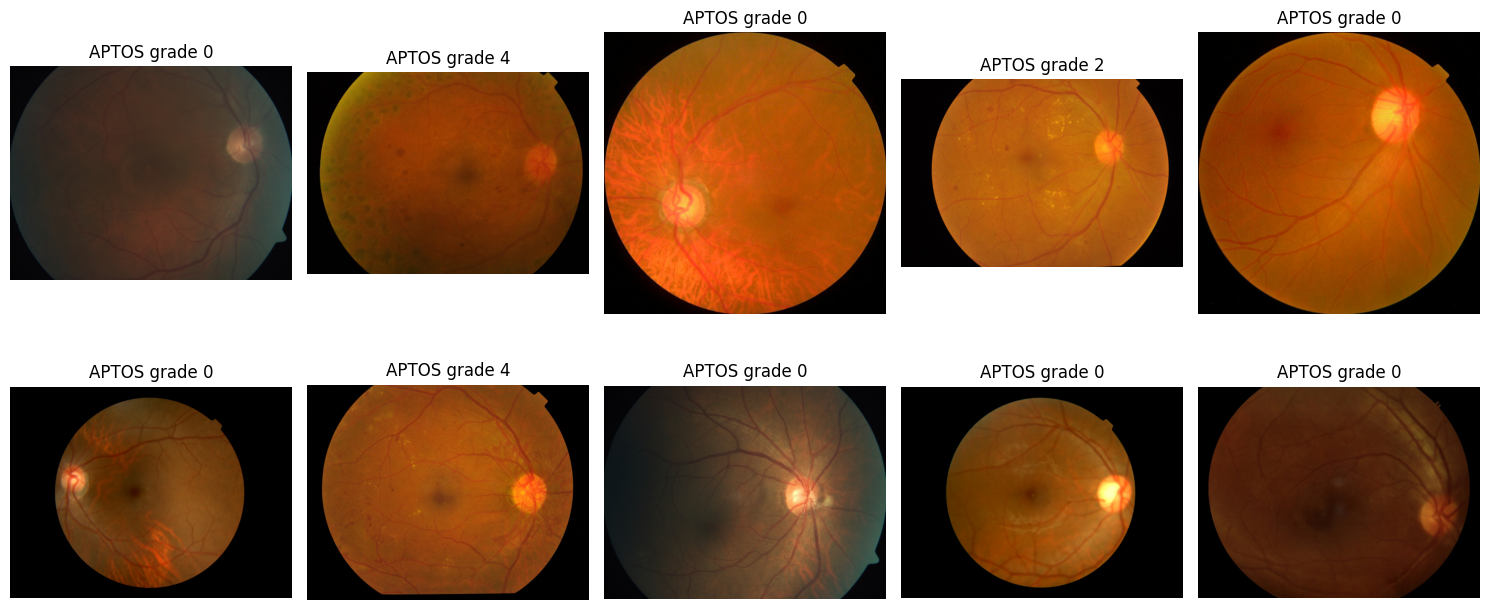

Verify visually that these are fundus photographs and that the labels come from the expected APTOS training CSV.


In [13]:
# Cell 14 — Visual classifier sanity check
sample = train_df.sample(min(10, len(train_df)), random_state=SEED)

plt.figure(figsize=(15, 7))

for i, (_, row) in enumerate(sample.iterrows(), start=1):
    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i)
    plt.imshow(img)
    plt.title(f"APTOS grade {row['label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "Verify visually that these are fundus photographs and that the labels "
    "come from the expected APTOS training CSV."
)


In [15]:
# Cell 15 — Build EfficientNetB0 DR-grade classifier
def build_classifier():

    # IMPORTANT:
    # Do NOT give EfficientNetB0 a custom name here.
    # Keras uses its model name while resolving ImageNet weight files.
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*CLS_SIZE, 3)
    )

    backbone.trainable = False

    inputs = keras.Input(
        shape=(*CLS_SIZE, 3),
        name="fundus"
    )

    # Keep pretrained BatchNorm statistics frozen.
    x = backbone(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D(
        name="gap"
    )(x)

    x = layers.Dropout(
        0.35,
        name="head_dropout"
    )(x)

    outputs = layers.Dense(
        5,
        activation="softmax",
        name="grade"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name="DR_EfficientNetB0"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model, backbone


model, cls_backbone = build_classifier()

print("Backbone name:", cls_backbone.name)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone name: efficientnetb0


Model: "DR_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fundus (InputLayer)             │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grade (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# Cell 16 — Classifier stage 1: train the new head
HEAD_CKPT = OUTPUT_ROOT / "classifier_head_best.keras"

head_callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(HEAD_CKPT),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

hist_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weight,
    callbacks=head_callbacks,
)

head_val_loss, head_val_acc = model.evaluate(val_ds, verbose=0)

print(
    f"Head-stage validation loss={head_val_loss:.4f}, "
    f"accuracy={head_val_acc:.4f}"
)


Epoch 1/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4347 - loss: 1.4840
Epoch 1: val_loss improved from None to 0.84094, saving model to /content/drive/MyDrive/sih/outputs_v3/classifier_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sih/outputs_v3/classifier_head_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 718s 3s/step - accuracy: 0.5439 - loss: 1.3265 - val_accuracy: 0.6703 - val_loss: 0.8409 - learning_rate: 0.0010
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6481 - loss: 1.0730
Epoch 2: val_loss improved from 0.84094 to 0.78442, saving model to /content/drive/MyDrive/sih/outputs_v3/classifier_head_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/sih/outputs_v3/classifier_head_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 640s 3s/step - accuracy: 0.6488 - loss: 1.0834 - val_accuracy: 0.7049 - val_loss: 0.7844 - learning_rate: 0.0010
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6705 - loss: 0.994

In [17]:
# Cell 17 — Classifier stage 2: conservative fine-tuning
cls_backbone.trainable = True

for layer in cls_backbone.layers[:-CLS_FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in cls_backbone.layers[-CLS_FINE_TUNE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Trainable backbone layers:",
    sum(int(l.trainable) for l in cls_backbone.layers),
    "/",
    len(cls_backbone.layers),
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ],
)

FINE_CKPT = OUTPUT_ROOT / "classifier_finetuned_best.keras"

fine_callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(FINE_CKPT),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

hist_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_EPOCHS,
    class_weight=class_weight,
    callbacks=fine_callbacks,
)

fine_val_loss, fine_val_acc = model.evaluate(val_ds, verbose=0)

print(
    f"Fine-tuned validation loss={fine_val_loss:.4f}, "
    f"accuracy={fine_val_acc:.4f}"
)


Trainable backbone layers: 27 / 238
Epoch 1/14
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7453 - loss: 0.8610
Epoch 1: val_loss improved from None to 0.67128, saving model to /content/drive/MyDrive/sih/outputs_v3/classifier_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sih/outputs_v3/classifier_finetuned_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - accuracy: 0.7405 - loss: 0.8657 - val_accuracy: 0.7359 - val_loss: 0.6713 - learning_rate: 1.0000e-05
Epoch 2/14
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7625 - loss: 0.7933
Epoch 2: val_loss did not improve from 0.67128
214/214 ━━━━━━━━━━━━━━━━━━━━ 638s 3s/step - accuracy: 0.7511 - loss: 0.8229 - val_accuracy: 0.7213 - val_loss: 0.7018 - learning_rate: 1.0000e-05
Epoch 3/14
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7451 - loss: 0.8387
Epoch 3: val_loss did not improve from 0.67128

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
214/2

In [18]:
# Cell 18 — Select the stronger classifier checkpoint
head_model = keras.models.load_model(HEAD_CKPT)
fine_model = keras.models.load_model(FINE_CKPT)

head_loss, head_acc = head_model.evaluate(val_ds, verbose=0)
fine_loss, fine_acc = fine_model.evaluate(val_ds, verbose=0)

if fine_loss <= head_loss:
    model = fine_model
    selected_classifier_stage = "fine_tuned"
else:
    model = head_model
    selected_classifier_stage = "head_only"

FINAL_CLASSIFIER = OUTPUT_ROOT / "aptos_efficientnetb0_final.keras"
model.save(FINAL_CLASSIFIER)

print("Head val loss/acc :", head_loss, head_acc)
print("Fine val loss/acc :", fine_loss, fine_acc)
print("Selected stage    :", selected_classifier_stage)
print("Saved             :", FINAL_CLASSIFIER)


Head val loss/acc : 0.6515423059463501 0.748633861541748
Fine val loss/acc : 0.6712790131568909 0.7358834147453308
Selected stage    : head_only
Saved             : /content/drive/MyDrive/sih/outputs_v3/aptos_efficientnetb0_final.keras


In [19]:
# Cell 19 — Temperature calibration on validation predictions
val_probs_raw = model.predict(val_ds, verbose=1)
test_probs_raw = model.predict(test_ds, verbose=1)

y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

def temperature_scale(probs, temperature):
    probs = np.clip(np.asarray(probs, np.float64), 1e-12, 1.0)
    logits = np.log(probs) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    e = np.exp(logits)
    return e / e.sum(axis=1, keepdims=True)

def objective(log_temperature):
    t = float(np.exp(log_temperature))
    calibrated = temperature_scale(val_probs_raw, t)
    return log_loss(
        y_val,
        calibrated,
        labels=[0, 1, 2, 3, 4]
    )

opt = minimize_scalar(
    objective,
    bounds=(np.log(0.05), np.log(10.0)),
    method="bounded",
)

temperature = float(np.exp(opt.x))

val_probs = temperature_scale(val_probs_raw, temperature)
test_probs = temperature_scale(test_probs_raw, temperature)

raw_nll = log_loss(
    y_val,
    val_probs_raw,
    labels=[0, 1, 2, 3, 4]
)
cal_nll = log_loss(
    y_val,
    val_probs,
    labels=[0, 1, 2, 3, 4]
)

print("Temperature:", temperature)
print("Validation NLL before:", raw_nll)
print("Validation NLL after :", cal_nll)


46/46 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step
Temperature: 0.8320230381499122
Validation NLL before: 0.651542327660762
Validation NLL after : 0.6429186272472526


In [20]:
# Cell 20 — Tune referable-DR threshold on validation only
# Referable DR is defined as grades 2, 3 or 4.

y_val_ref = (y_val >= 2).astype(int)
p_val_ref = val_probs[:, 2:].sum(axis=1)

fpr, tpr, thresholds = roc_curve(y_val_ref, p_val_ref)

valid_idx = np.where(
    np.isfinite(thresholds)
    & (thresholds >= 0.0)
    & (thresholds <= 1.0)
)[0]

if len(valid_idx) == 0:
    raise RuntimeError("ROC threshold calculation returned no finite thresholds.")

eligible = valid_idx[tpr[valid_idx] >= 0.90]

if len(eligible):
    # Maximize specificity while meeting the sensitivity target.
    best_i = eligible[np.argmax(1.0 - fpr[eligible])]
    threshold_rule = ">=90% validation sensitivity, then maximum specificity"
else:
    # If the validation ROC cannot reach the target, use Youden J.
    best_i = valid_idx[np.argmax(tpr[valid_idx] - fpr[valid_idx])]
    threshold_rule = "Youden J fallback (90% validation sensitivity not attainable)"
    print("WARNING:", threshold_rule)

REF_THRESHOLD = float(thresholds[best_i])

val_pred_ref = (p_val_ref >= REF_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(
    y_val_ref,
    val_pred_ref,
    labels=[0, 1],
).ravel()

val_sens = tp / (tp + fn) if (tp + fn) else np.nan
val_spec = tn / (tn + fp) if (tn + fp) else np.nan
val_auc = roc_auc_score(y_val_ref, p_val_ref)

print("Threshold rule       :", threshold_rule)
print("Referable threshold  :", REF_THRESHOLD)
print("Validation AUC       :", val_auc)
print("Validation sensitivity:", val_sens)
print("Validation specificity:", val_spec)


Threshold rule       : >=90% validation sensitivity, then maximum specificity
Referable threshold  : 0.3188608191210113
Validation AUC       : 0.96903628710556
Validation sensitivity: 0.905829596412556
Validation specificity: 0.9141104294478528


FINAL HELD-OUT APTOS RESULTS
5-class accuracy      : 0.7727272727272727
Quadratic weighted κ  : 0.8201732875592611
Referable-DR AUC      : 0.9698852182498869
Sensitivity           : 0.905829596412556
Specificity           : 0.8899082568807339
Fixed referral thresh : 0.3188608191210113

5-class report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       271
           1       0.52      0.57      0.55        56
           2       0.76      0.65      0.70       150
           3       0.38      0.41      0.39        29
           4       0.43      0.41      0.42        44

    accuracy                           0.77       550
   macro avg       0.60      0.60      0.60       550
weighted avg       0.77      0.77      0.77       550



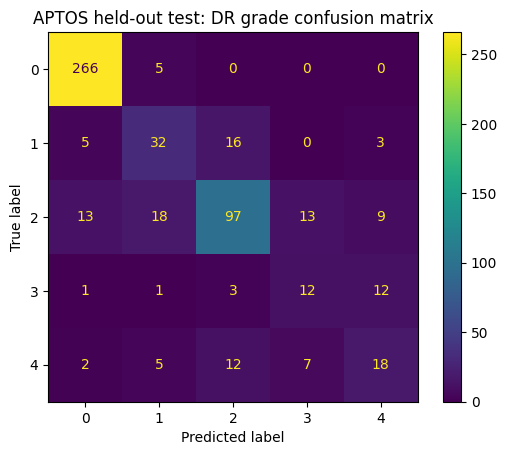

In [21]:
# Cell 21 — Final held-out APTOS test evaluation
test_grade_pred = np.argmax(test_probs, axis=1)

test_accuracy = accuracy_score(y_test, test_grade_pred)
test_qwk = cohen_kappa_score(
    y_test,
    test_grade_pred,
    weights="quadratic",
)

y_test_ref = (y_test >= 2).astype(int)
p_test_ref = test_probs[:, 2:].sum(axis=1)
test_ref_pred = (p_test_ref >= REF_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_ref,
    test_ref_pred,
    labels=[0, 1],
).ravel()

test_sens = tp / (tp + fn) if (tp + fn) else np.nan
test_spec = tn / (tn + fp) if (tn + fp) else np.nan

test_auc = (
    roc_auc_score(y_test_ref, p_test_ref)
    if len(np.unique(y_test_ref)) == 2
    else np.nan
)

print("=" * 72)
print("FINAL HELD-OUT APTOS RESULTS")
print("=" * 72)
print("5-class accuracy      :", test_accuracy)
print("Quadratic weighted κ  :", test_qwk)
print("Referable-DR AUC      :", test_auc)
print("Sensitivity           :", test_sens)
print("Specificity           :", test_spec)
print("Fixed referral thresh :", REF_THRESHOLD)

print("\n5-class report:")
print(
    classification_report(
        y_test,
        test_grade_pred,
        labels=[0, 1, 2, 3, 4],
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_grade_pred,
    labels=[0, 1, 2, 3, 4],
)
plt.title("APTOS held-out test: DR grade confusion matrix")
plt.show()


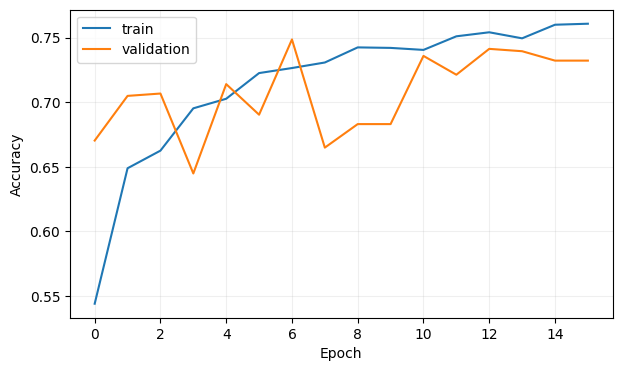

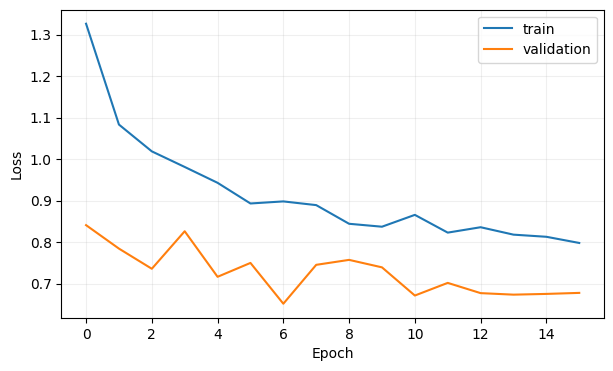

In [22]:
# Cell 22 — Classifier learning curves
def combine_history(a, b, key):
    values = []
    if a is not None:
        values += a.history.get(key, [])
    if b is not None:
        values += b.history.get(key, [])
    return values

plt.figure(figsize=(7, 4))
plt.plot(combine_history(hist_head, hist_fine, "accuracy"), label="train")
plt.plot(combine_history(hist_head, hist_fine, "val_accuracy"), label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(combine_history(hist_head, hist_fine, "loss"), label="train")
plt.plot(combine_history(hist_head, hist_fine, "val_loss"), label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [23]:
# Cell 23 — Robust Grad-CAM builder

def build_gradcam_model(classifier):

    # EfficientNet keeps its default name so ImageNet
    # weights can load correctly.
    backbone = classifier.get_layer(
        "efficientnetb0"
    )

    # Last convolutional layer inside EfficientNetB0
    last_conv = backbone.get_layer(
        "top_conv"
    )

    feature_extractor = keras.Model(
        inputs=backbone.input,
        outputs=[
            last_conv.output,
            backbone.output
        ],
        name="gradcam_feature_extractor"
    )

    grad_input = keras.Input(
        shape=(*CLS_SIZE, 3)
    )

    conv_features, backbone_features = (
        feature_extractor(
            grad_input,
            training=False
        )
    )

    x = classifier.get_layer(
        "gap"
    )(backbone_features)

    x = classifier.get_layer(
        "head_dropout"
    )(
        x,
        training=False
    )

    preds = classifier.get_layer(
        "grade"
    )(x)

    return keras.Model(
        grad_input,
        [
            conv_features,
            preds
        ],
        name="gradcam_model"
    )


grad_model = build_gradcam_model(
    model
)


def load_classifier_image_eager(filepath):

    return decode_classifier_image(
        tf.constant(str(filepath))
    ).numpy().astype(
        np.float32
    )


def make_gradcam(
    classifier_image,
    class_index=None
):

    x = tf.convert_to_tensor(
        classifier_image[
            None, ...
        ],
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        conv_features, preds = (
            grad_model(
                x,
                training=False
            )
        )

        if class_index is None:
            class_index = int(
                tf.argmax(
                    preds[0]
                )
            )

        score = preds[
            :,
            class_index
        ]

    grads = tape.gradient(
        score,
        conv_features
    )

    weights = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    cam = tf.reduce_sum(
        conv_features
        * weights[
            :, None, None, :
        ],
        axis=-1
    )[0]

    cam = tf.maximum(
        cam,
        0
    )

    cam = cam / (
        tf.reduce_max(cam)
        + 1e-8
    )

    cam = cv2.resize(
        cam.numpy(),
        (
            CLS_SIZE[1],
            CLS_SIZE[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    return (
        cam,
        preds.numpy()[0],
        class_index
    )


sample_cls = load_classifier_image_eager(
    test_df.iloc[0][
        "filepath"
    ]
)

sample_cam, sample_probs, sample_pred = (
    make_gradcam(
        sample_cls
    )
)

print(
    "Sample predicted grade:",
    sample_pred
)

print(
    "Raw class probabilities:",
    sample_probs
)

Sample predicted grade: 2
Raw class probabilities: [0.01744755 0.18192452 0.50544894 0.11827907 0.17689995]


In [24]:
# Cell 24 — Build a reliable IDRiD lesion-mask manifest
# The model predicts the UNION of MA/HE/EX/SE.
# OD (optic disc) is not used as a lesion target.

LESION_CODES = ["MA", "HE", "EX", "SE"]

all_idrid_files = [
    p for p in Path(idrid_seg_root).rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

mask_map = {}
original_map = {}

for p in all_idrid_files:
    stem = p.stem
    parts = stem.split("_")

    code = parts[-1].upper() if len(parts) >= 2 else None

    if code in LESION_CODES or code == "OD":
        base_id = "_".join(parts[:-1]).lower()
        mask_map[(base_id, code)] = str(p)
    else:
        base_id = stem.lower()

        # Prefer images explicitly stored under an "Original Images" path.
        path_text = str(p).lower()
        priority = 0 if "original image" in path_text else 1

        current = original_map.get(base_id)
        if current is None or priority < current[0]:
            original_map[base_id] = (priority, str(p))

rows = []

for base_id, (_, image_path) in original_map.items():
    lesion_masks = {
        code: mask_map.get((base_id, code))
        for code in LESION_CODES
    }

    # Only use images for which at least one lesion annotation file was found.
    # This avoids treating an ambiguous missing annotation as a true negative.
    n_masks = sum(v is not None for v in lesion_masks.values())

    if n_masks == 0:
        continue

    row = {
        "base_id": base_id,
        "filepath": image_path,
        "mask_count": n_masks,
    }

    for code in LESION_CODES:
        row[code + "_mask"] = lesion_masks[code]

    rows.append(row)

if not rows:
    raise ValueError(
        "No IDRiD image/mask pairs were discovered. "
        "Check that the A. Segmentation package extracted correctly."
    )

seg_df = pd.DataFrame(rows).sort_values("base_id").reset_index(drop=True)

print("IDRiD images with lesion annotations:", len(seg_df))
print("Discovered mask counts:")
print(Counter(code for (_, code) in mask_map if code in LESION_CODES))

if len(seg_df) < 20:
    raise ValueError(
        f"Only {len(seg_df)} IDRiD images with lesion masks were matched. "
        "Check the extracted segmentation package and naming."
    )

display(seg_df.head())


IDRiD images with lesion annotations: 81
Discovered mask counts:
Counter({'EX': 81, 'MA': 81, 'HE': 80, 'SE': 40})


,base_id,filepath,mask_count,MA_mask,HE_mask,EX_mask,SE_mask
0,idrid_01,/content/dr_work/IDRiD_Segmentation/A. Segment...,3,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,None
1,idrid_02,/content/dr_work/IDRiD_Segmentation/A. Segment...,3,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,None
2,idrid_03,/content/dr_work/IDRiD_Segmentation/A. Segment...,4,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...
3,idrid_04,/content/dr_work/IDRiD_Segmentation/A. Segment...,3,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,None
4,idrid_05,/content/dr_work/IDRiD_Segmentation/A. Segment...,3,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,/content/dr_work/IDRiD_Segmentation/A. Segment...,None


In [25]:
# Cell 25 — Preload aligned IDRiD image / lesion-union mask arrays
def resize_aligned_mask(mask_path, original_hw, bbox):
    if mask_path is None or not os.path.exists(mask_path):
        return np.zeros(SEG_SIZE, np.uint8)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return np.zeros(SEG_SIZE, np.uint8)

    orig_h, orig_w = original_hw

    if mask.shape[:2] != (orig_h, orig_w):
        mask = cv2.resize(
            mask,
            (orig_w, orig_h),
            interpolation=cv2.INTER_NEAREST,
        )

    y0, y1, x0, x1 = bbox
    mask = mask[y0:y1, x0:x1]

    mask = cv2.resize(
        mask,
        (SEG_SIZE[1], SEG_SIZE[0]),
        interpolation=cv2.INTER_NEAREST,
    )

    return (mask > 0).astype(np.uint8)

def prepare_idrid_sample(row):
    bgr = cv2.imread(row["filepath"])

    if bgr is None:
        raise ValueError(f"Unreadable IDRiD image: {row['filepath']}")

    orig_h, orig_w = bgr.shape[:2]
    bbox = fundus_bbox_bgr(bgr)

    y0, y1, x0, x1 = bbox
    crop = bgr[y0:y1, x0:x1]

    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(
        rgb,
        (SEG_SIZE[1], SEG_SIZE[0]),
        interpolation=cv2.INTER_AREA,
    )

    union = np.zeros(SEG_SIZE, np.uint8)

    for code in LESION_CODES:
        m = resize_aligned_mask(
            row.get(code + "_mask"),
            original_hw=(orig_h, orig_w),
            bbox=bbox,
        )
        union = np.maximum(union, m)

    return rgb.astype(np.float32), union[..., None].astype(np.float32)

X_seg = []
Y_seg = []
seg_ids = []

for _, row in tqdm(seg_df.iterrows(), total=len(seg_df), desc="Preload IDRiD"):
    try:
        x, y = prepare_idrid_sample(row)
        X_seg.append(x)
        Y_seg.append(y)
        seg_ids.append(row["base_id"])
    except Exception as e:
        print("Skipping:", row["base_id"], e)

X_seg = np.stack(X_seg).astype(np.float32)
Y_seg = np.stack(Y_seg).astype(np.float32)

positive_fraction = float(Y_seg.mean())

print("X_seg:", X_seg.shape, X_seg.dtype)
print("Y_seg:", Y_seg.shape, Y_seg.dtype)
print("Overall lesion-positive pixel fraction:", positive_fraction)

if len(X_seg) < 20:
    raise RuntimeError("Too few valid segmentation samples after loading.")

if positive_fraction <= 1e-5:
    raise RuntimeError(
        "Lesion masks are essentially empty. "
        "Do not train; inspect IDRiD image/mask matching."
    )


Preload IDRiD:   0%|          | 0/81 [00:00<?, ?it/s]

X_seg: (81, 384, 384, 3) float32
Y_seg: (81, 384, 384, 1) float32
Overall lesion-positive pixel fraction: 0.02735915593802929


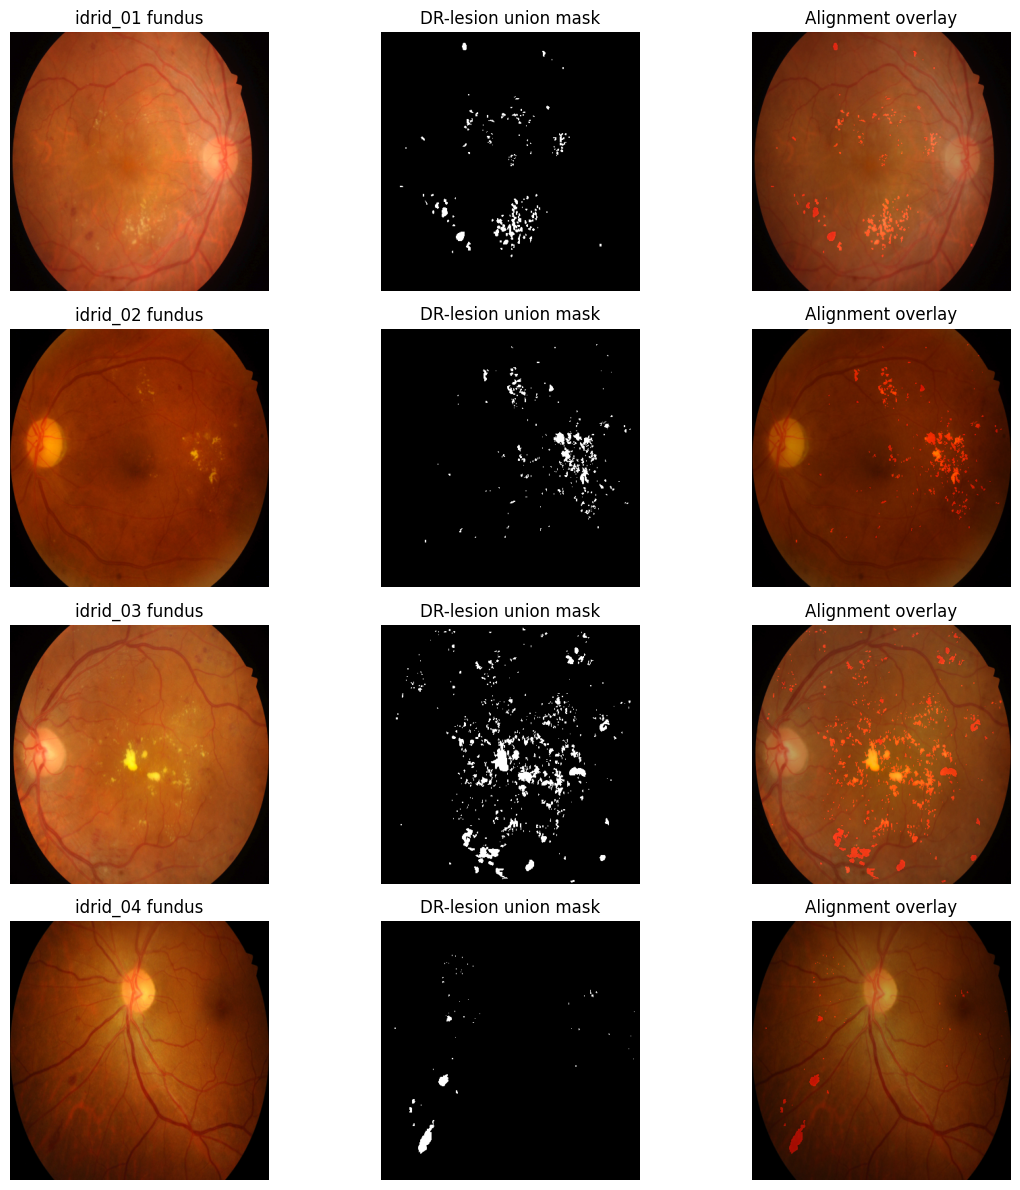

IMPORTANT: lesion masks should lie on actual retinal abnormalities. If the masks are shifted or blank, stop here and fix the dataset.


In [26]:
# Cell 26 — Mandatory IDRiD mask sanity visualization
n_show = min(4, len(X_seg))

plt.figure(figsize=(12, 3 * n_show))

for i in range(n_show):
    plt.subplot(n_show, 3, i * 3 + 1)
    plt.imshow(X_seg[i].astype(np.uint8))
    plt.title(f"{seg_ids[i]} fundus")
    plt.axis("off")

    plt.subplot(n_show, 3, i * 3 + 2)
    plt.imshow(Y_seg[i, ..., 0], cmap="gray")
    plt.title("DR-lesion union mask")
    plt.axis("off")

    overlay = X_seg[i] / 255.0
    lesion = Y_seg[i, ..., 0]
    heat = np.zeros_like(overlay)
    heat[..., 0] = lesion
    combined = np.clip(0.75 * overlay + 0.45 * heat, 0, 1)

    plt.subplot(n_show, 3, i * 3 + 3)
    plt.imshow(combined)
    plt.title("Alignment overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "IMPORTANT: lesion masks should lie on actual retinal abnormalities. "
    "If the masks are shifted or blank, stop here and fix the dataset."
)


In [27]:
# Cell 27 — Split segmentation data and create paired augmentation datasets
indices = np.arange(len(X_seg))

seg_train_idx, seg_val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
)

X_seg_train = X_seg[seg_train_idx]
Y_seg_train = Y_seg[seg_train_idx]
X_seg_val = X_seg[seg_val_idx]
Y_seg_val = Y_seg[seg_val_idx]

def paired_seg_augment(image, mask):
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)

    # Same geometric operations for image and mask.
    do_flip = tf.random.uniform([]) < 0.5
    image = tf.cond(do_flip, lambda: tf.image.flip_left_right(image), lambda: image)
    mask = tf.cond(do_flip, lambda: tf.image.flip_left_right(mask), lambda: mask)

    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    # Photometric augmentation affects the image only.
    image = tf.image.random_brightness(image, max_delta=10.0)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    image = tf.clip_by_value(image, 0.0, 255.0)

    mask = tf.cast(mask >= 0.5, tf.float32)

    return image, mask

seg_train_ds = tf.data.Dataset.from_tensor_slices(
    (X_seg_train, Y_seg_train)
)
seg_train_ds = seg_train_ds.shuffle(
    len(X_seg_train),
    seed=SEED,
    reshuffle_each_iteration=True,
)
seg_train_ds = seg_train_ds.map(
    paired_seg_augment,
    num_parallel_calls=AUTOTUNE,
)
seg_train_ds = seg_train_ds.batch(SEG_BATCH).prefetch(AUTOTUNE)

seg_val_ds = tf.data.Dataset.from_tensor_slices(
    (X_seg_val, Y_seg_val)
)
seg_val_ds = seg_val_ds.batch(SEG_BATCH).prefetch(AUTOTUNE)

print("Seg train samples:", len(X_seg_train))
print("Seg val samples  :", len(X_seg_val))
print("Known train batches:", int(tf.data.experimental.cardinality(seg_train_ds).numpy()))
print("Known val batches  :", int(tf.data.experimental.cardinality(seg_val_ds).numpy()))


Seg train samples: 64
Seg val samples  : 17
Known train batches: 16
Known val batches  : 5


In [28]:
# Cell 28 — Focal + Tversky segmentation objective and metrics
# Positive lesions are sparse, so the positive focal weight is automatically
# derived from the observed training-mask foreground fraction.

train_pos_fraction = float(Y_seg_train.mean())
SEG_ALPHA = float(np.clip(1.0 - train_pos_fraction, 0.75, 0.95))
SEG_GAMMA = 2.0

print("Training lesion fraction:", train_pos_fraction)
print("Focal positive alpha    :", SEG_ALPHA)

def soft_dice_numpy(y_true, y_prob, eps=1e-7):
    y_true = np.asarray(y_true, np.float64)
    y_prob = np.asarray(y_prob, np.float64)
    inter = np.sum(y_true * y_prob)
    return float(
        (2.0 * inter + eps)
        / (np.sum(y_true) + np.sum(y_prob) + eps)
    )

def hard_dice_numpy(y_true, y_prob, threshold=0.5, eps=1e-7):
    pred = y_prob >= threshold
    true = y_true >= 0.5
    inter = np.logical_and(pred, true).sum()
    return float(
        (2.0 * inter + eps)
        / (pred.sum() + true.sum() + eps)
    )

def hard_iou_numpy(y_true, y_prob, threshold=0.5, eps=1e-7):
    pred = y_prob >= threshold
    true = y_true >= 0.5
    inter = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()
    return float((inter + eps) / (union + eps))

@keras.utils.register_keras_serializable(package="DR")
def soft_dice_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    axes = (1, 2, 3)
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)

    dice = (2.0 * inter + 1e-6) / (denom + 1e-6)
    return tf.reduce_mean(dice)

@keras.utils.register_keras_serializable(package="DR")
def hard_iou_metric(y_true, y_pred):
    y_true = tf.cast(y_true >= 0.5, tf.float32)
    y_pred = tf.cast(y_pred >= 0.5, tf.float32)

    axes = (1, 2, 3)
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true + y_pred, axis=axes) - inter

    iou = (inter + 1e-6) / (union + 1e-6)
    return tf.reduce_mean(iou)

def make_seg_loss(alpha=SEG_ALPHA, gamma=SEG_GAMMA):
    alpha = tf.constant(alpha, tf.float32)
    gamma = tf.constant(gamma, tf.float32)

    def loss(y_true, y_pred):
        y_true_f = tf.cast(y_true, tf.float32)
        y_pred_f = tf.clip_by_value(
            tf.cast(y_pred, tf.float32),
            1e-6,
            1.0 - 1e-6,
        )

        # Pixelwise alpha-balanced focal loss.
        pt = y_true_f * y_pred_f + (1.0 - y_true_f) * (1.0 - y_pred_f)
        alpha_t = y_true_f * alpha + (1.0 - y_true_f) * (1.0 - alpha)

        focal = -alpha_t * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        focal = tf.reduce_mean(focal)

        # Tversky: beta > alpha_fp penalizes missed lesions more than false positives.
        axes = (1, 2, 3)
        tp = tf.reduce_sum(y_true_f * y_pred_f, axis=axes)
        fp = tf.reduce_sum((1.0 - y_true_f) * y_pred_f, axis=axes)
        fn = tf.reduce_sum(y_true_f * (1.0 - y_pred_f), axis=axes)

        alpha_fp = 0.30
        beta_fn = 0.70

        tversky = (tp + 1e-6) / (
            tp + alpha_fp * fp + beta_fn * fn + 1e-6
        )
        tversky_loss = 1.0 - tf.reduce_mean(tversky)

        return focal + tversky_loss

    return loss

SEG_LOSS = make_seg_loss()


Training lesion fraction: 0.02790207415819168
Focal positive alpha    : 0.95


In [29]:
# Cell 29 — Pretrained MobileNetV2 U-Net lesion segmenter
def decoder_block(x, skip, filters, name):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size=3,
        strides=2,
        padding="same",
        use_bias=False,
        name=name + "_up",
    )(x)

    x = layers.Concatenate(name=name + "_concat")([x, skip])

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        name=name + "_conv1",
    )(x)
    x = layers.BatchNormalization(name=name + "_bn1")(x)
    x = layers.Activation("relu", name=name + "_relu1")(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        name=name + "_conv2",
    )(x)
    x = layers.BatchNormalization(name=name + "_bn2")(x)
    x = layers.Activation("relu", name=name + "_relu2")(x)

    return x

def build_lesion_unet():
    base = keras.applications.MobileNetV2(
        input_shape=(*SEG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )

    skip_names = [
        "block_1_expand_relu",   # 1/2
        "block_3_expand_relu",   # 1/4
        "block_6_expand_relu",   # 1/8
        "block_13_expand_relu",  # 1/16
        "block_16_project",      # 1/32
    ]

    down_stack = keras.Model(
        base.input,
        [base.get_layer(name).output for name in skip_names],
        name="mobilenetv2_encoder",
    )
    down_stack.trainable = False

    inputs = keras.Input((*SEG_SIZE, 3), name="seg_fundus")

    # MobileNetV2 expects [-1, 1].
    x = layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1.0,
        name="mobilenet_preprocess",
    )(inputs)

    features = down_stack(x, training=False)

    s1, s2, s3, s4, bottleneck = features

    x = decoder_block(bottleneck, s4, 256, "dec4")
    x = decoder_block(x, s3, 128, "dec3")
    x = decoder_block(x, s2, 64, "dec2")
    x = decoder_block(x, s1, 32, "dec1")

    x = layers.Conv2DTranspose(
        24,
        3,
        strides=2,
        padding="same",
        activation="relu",
        name="final_up",
    )(x)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid",
        name="lesion_probability",
    )(x)

    model = keras.Model(inputs, outputs, name="IDRiD_Lesion_UNet")
    return model, down_stack

seg_model, seg_encoder = build_lesion_unet()

seg_model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss=SEG_LOSS,
    metrics=[soft_dice_metric, hard_iou_metric],
)

seg_model.summary()


/tmp/ipykernel_1515/2614612241.py:37: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "IDRiD_Lesion_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seg_fundus          │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_preproce… │ (None, 384, 384,  │          0 │ seg_fundus[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 192, 192, │  1,841,984 │ mobilenet_prepro… │
│ (Functional)        │ 96), (None, 96,   │            │                   │
│                     │ 96, 144), (None,  │            │                   │
│                     │ 48, 48, 192),     │            │                   │
│                     │ (None, 24, 24,    │            │                   │
│                     │ 576), (None, 12,  │            │                   │
│                     │ 12, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_up             │ (None, 24, 24,    │    737,280 │ mobilenetv2_enco… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_concat         │ (None, 24, 24,    │          0 │ dec4_up[0][0],    │
│ (Concatenate)       │ 832)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_conv1 (Conv2D) │ (None, 24, 24,    │  1,916,928 │ dec4_concat[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_bn1            │ (None, 24, 24,    │      1,024 │ dec4_conv1[0][0]  │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_relu1          │ (None, 24, 24,    │          0 │ dec4_bn1[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_conv2 (Conv2D) │ (None, 24, 24,    │    589,824 │ dec4_relu1[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_bn2            │ (None, 24, 24,    │      1,024 │ dec4_conv2[0][0]  │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec4_relu2          │ (None, 24, 24,    │          0 │ dec4_bn2[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_up             │ (None, 48, 48,    │    294,912 │ dec4_relu2[0][0]  │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_concat         │ (None, 48, 48,    │          0 │ dec3_up[0][0],    │
│ (Concatenate)       │ 320)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv1 (Conv2D) │ (None, 48, 48,    │    368,640 │ dec3_concat[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_bn1            │ (None, 48, 48,    │        512 │ dec3_conv1[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                 

 Total params: 6,202,737 (23.66 MB)

 Trainable params: 4,358,833 (16.63 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

In [30]:
# Cell 30 — Segmentation stage 1: train decoder with encoder frozen
SEG_STAGE1_WEIGHTS = OUTPUT_ROOT / "seg_stage1_best.weights.h5"

seg_stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(SEG_STAGE1_WEIGHTS),
        monitor="val_soft_dice_metric",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_soft_dice_metric",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.35,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

hist_seg1 = seg_model.fit(
    seg_train_ds,
    validation_data=seg_val_ds,
    epochs=SEG_STAGE1_EPOCHS,
    callbacks=seg_stage1_callbacks,
)

print("Stage-1 best weights:", SEG_STAGE1_WEIGHTS)


Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - hard_iou_metric: 0.0359 - loss: 0.9295 - soft_dice_metric: 0.0591
Epoch 1: val_soft_dice_metric improved from None to 0.04626, saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage1_best.weights.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - hard_iou_metric: 0.0371 - loss: 0.9357 - soft_dice_metric: 0.0525 - val_hard_iou_metric: 0.0247 - val_loss: 0.9382 - val_soft_dice_metric: 0.0463 - learning_rate: 2.0000e-04
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - hard_iou_metric: 0.0657 - loss: 0.9088 - soft_dice_metric: 0.0702
Epoch 2: val_soft_dice_metric improved from 0.04626 to 0.05914, saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage1_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage1_best.weights.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - hard_iou_metric: 

In [31]:
# Cell 31 — Segmentation stage 2: fine-tune final encoder layers
seg_encoder.trainable = True

for layer in seg_encoder.layers[:-SEG_FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in seg_encoder.layers[-SEG_FINE_TUNE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Trainable encoder layers:",
    sum(int(l.trainable) for l in seg_encoder.layers),
    "/",
    len(seg_encoder.layers),
)

seg_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=SEG_LOSS,
    metrics=[soft_dice_metric, hard_iou_metric],
)

SEG_STAGE2_WEIGHTS = OUTPUT_ROOT / "seg_stage2_best.weights.h5"

seg_stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(SEG_STAGE2_WEIGHTS),
        monitor="val_soft_dice_metric",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_soft_dice_metric",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.35,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

hist_seg2 = seg_model.fit(
    seg_train_ds,
    validation_data=seg_val_ds,
    epochs=SEG_STAGE2_EPOCHS,
    callbacks=seg_stage2_callbacks,
)

print("Stage-2 best weights:", SEG_STAGE2_WEIGHTS)


Trainable encoder layers: 24 / 150
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - hard_iou_metric: 0.2774 - loss: 0.6454 - soft_dice_metric: 0.2858
Epoch 1: val_soft_dice_metric improved from None to 0.21242, saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage2_best.weights.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - hard_iou_metric: 0.2768 - loss: 0.6585 - soft_dice_metric: 0.2810 - val_hard_iou_metric: 0.2772 - val_loss: 0.7700 - val_soft_dice_metric: 0.2124 - learning_rate: 1.0000e-05
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - hard_iou_metric: 0.3093 - loss: 0.6382 - soft_dice_metric: 0.2985
Epoch 2: val_soft_dice_metric improved from 0.21242 to 0.23172, saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage2_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/sih/outputs_v3/seg_stage2_best.weights.h5
16/16 ━━━━━━━━━━━━━━━━━━━

In [32]:
# Cell 32 — Select best segmentation checkpoint and tune probability threshold
def evaluate_seg_weights(weights_path):
    seg_model.load_weights(weights_path)
    prob = seg_model.predict(seg_val_ds, verbose=0)

    thresholds = np.arange(0.10, 0.91, 0.05)

    scores = [
        hard_dice_numpy(Y_seg_val, prob, t)
        for t in thresholds
    ]

    best_i = int(np.argmax(scores))

    return {
        "weights": str(weights_path),
        "probs": prob,
        "threshold": float(thresholds[best_i]),
        "dice": float(scores[best_i]),
        "soft_dice": soft_dice_numpy(Y_seg_val, prob),
    }

seg_stage1_eval = evaluate_seg_weights(SEG_STAGE1_WEIGHTS)
seg_stage2_eval = evaluate_seg_weights(SEG_STAGE2_WEIGHTS)

if seg_stage2_eval["dice"] >= seg_stage1_eval["dice"]:
    selected_seg = seg_stage2_eval
    selected_seg_stage = "fine_tuned"
else:
    selected_seg = seg_stage1_eval
    selected_seg_stage = "decoder_only"

SEG_THRESHOLD = selected_seg["threshold"]

seg_model.load_weights(selected_seg["weights"])

FINAL_SEG_WEIGHTS = OUTPUT_ROOT / "idrid_lesion_unet_final.weights.h5"
seg_model.save_weights(FINAL_SEG_WEIGHTS)

val_seg_probs = seg_model.predict(seg_val_ds, verbose=0)

seg_val_dice = hard_dice_numpy(
    Y_seg_val,
    val_seg_probs,
    SEG_THRESHOLD,
)
seg_val_iou = hard_iou_numpy(
    Y_seg_val,
    val_seg_probs,
    SEG_THRESHOLD,
)

pred_bin = val_seg_probs >= SEG_THRESHOLD
true_bin = Y_seg_val >= 0.5

tp = np.logical_and(pred_bin, true_bin).sum()
fp = np.logical_and(pred_bin, ~true_bin).sum()
fn = np.logical_and(~pred_bin, true_bin).sum()

seg_precision = tp / (tp + fp) if (tp + fp) else np.nan
seg_recall = tp / (tp + fn) if (tp + fn) else np.nan

print("Stage 1:", {k:v for k,v in seg_stage1_eval.items() if k != "probs"})
print("Stage 2:", {k:v for k,v in seg_stage2_eval.items() if k != "probs"})
print("\nSelected segmentation stage:", selected_seg_stage)
print("Tuned probability threshold :", SEG_THRESHOLD)
print("Validation Dice            :", seg_val_dice)
print("Validation IoU             :", seg_val_iou)
print("Validation precision       :", seg_precision)
print("Validation recall          :", seg_recall)
print("Saved final weights        :", FINAL_SEG_WEIGHTS)

SEGMENTATION_RELIABLE = bool(seg_val_dice >= 0.15)

if not SEGMENTATION_RELIABLE:
    print(
        "\nWARNING: segmentation validation Dice is still low. "
        "The notebook will label segmentation as experimental in reports "
        "rather than presenting it as a reliable clinical localization."
    )


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 90 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Stage 1: {'weights': '/content/drive/MyDrive/sih/outputs_v3/seg_stage1_best.weights.h5', 'threshold': 0.30000000000000004, 'dice': 0.5162393689144612, 'soft_dice': 0.25599203825245864}
Stage 2: {'weights': '/content/drive/MyDrive/sih/outputs_v3/seg_stage2_best.weights.h5', 'threshold': 0.8500000000000002, 'dice': 0.5435399836088107, 'soft_dice': 0.3751456420532987}

Selected segmentation stage: fine_tuned
Tuned probability threshold : 0.8500000000000002
Validation Dice            : 0.5435399836088107
Validation IoU             : 0.3731925198716067
Validation precision       : 0.5073841824118475
Validation recall          : 0.5852440158212389
Saved final weights        : /content/drive/MyDrive/sih/outputs_v3/idrid_lesion_unet_final.weights.h5


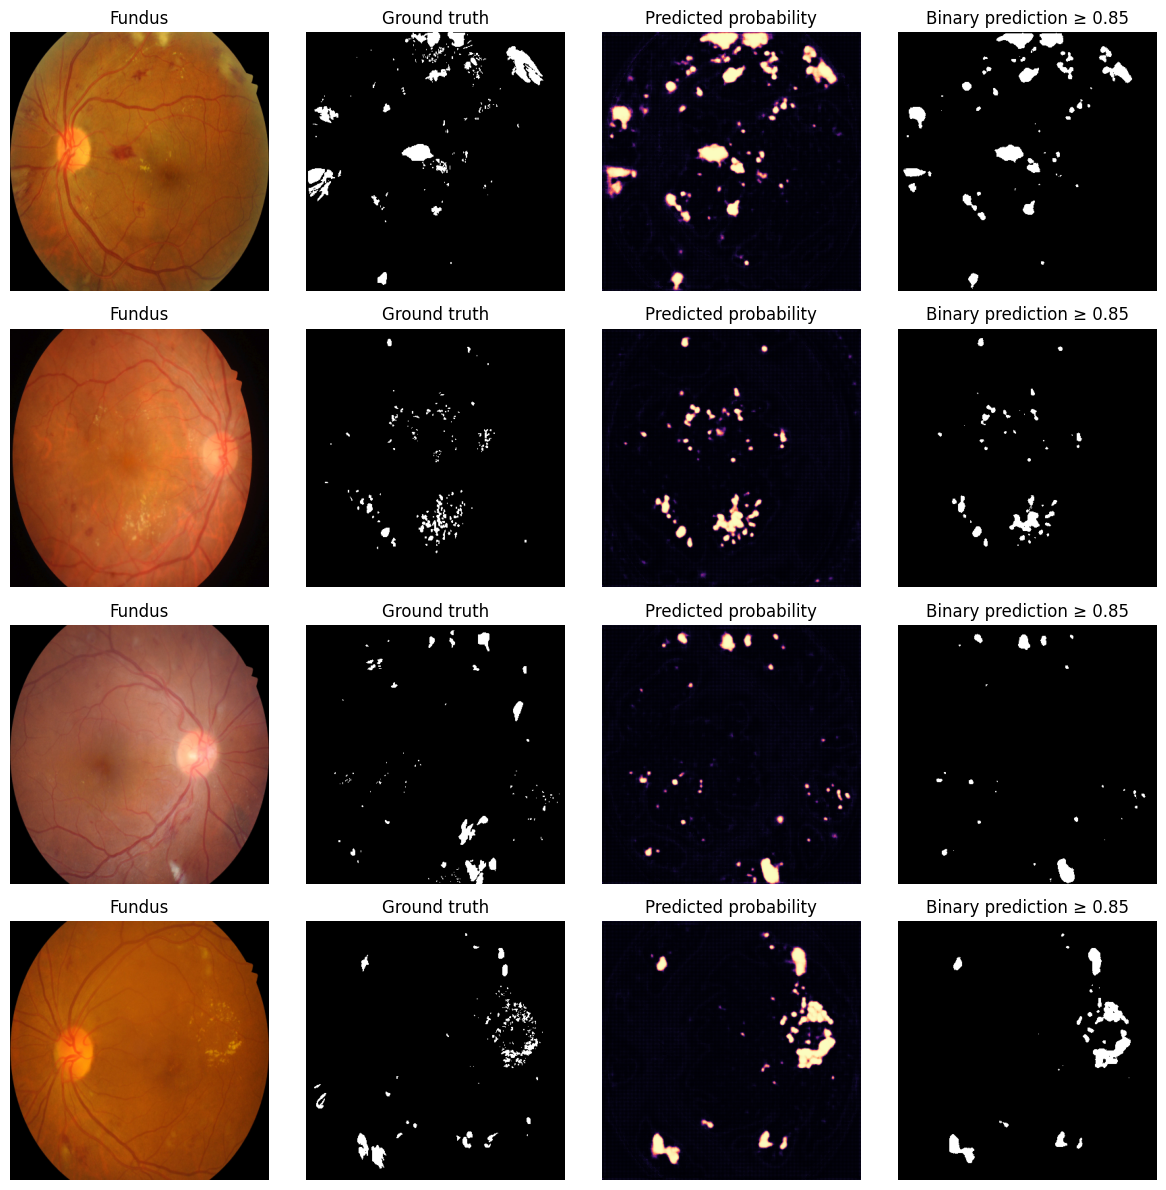

In [33]:
# Cell 33 — Segmentation validation examples
n = min(4, len(X_seg_val))
probs = seg_model.predict(X_seg_val[:n], verbose=0)

plt.figure(figsize=(12, 3 * n))

for i in range(n):
    pred = (probs[i, ..., 0] >= SEG_THRESHOLD).astype(np.float32)

    plt.subplot(n, 4, i * 4 + 1)
    plt.imshow(X_seg_val[i].astype(np.uint8))
    plt.title("Fundus")
    plt.axis("off")

    plt.subplot(n, 4, i * 4 + 2)
    plt.imshow(Y_seg_val[i, ..., 0], cmap="gray")
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(n, 4, i * 4 + 3)
    plt.imshow(probs[i, ..., 0], cmap="magma")
    plt.title("Predicted probability")
    plt.axis("off")

    plt.subplot(n, 4, i * 4 + 4)
    plt.imshow(pred, cmap="gray")
    plt.title(f"Binary prediction ≥ {SEG_THRESHOLD:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [34]:
# Cell 34 — Ground-truth lesion mask / Grad-CAM spatial overlap on IDRiD
def prepare_classifier_from_bgr(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    t = tf.convert_to_tensor(rgb, dtype=tf.float32)

    # Reuse the exact classifier crop/resize logic.
    t = tf_crop_black_border(t)
    t = tf.image.resize(t, CLS_SIZE, antialias=True)
    return tf.clip_by_value(t, 0.0, 255.0).numpy()

def idrid_union_for_cam(row):
    bgr = cv2.imread(row["filepath"])
    orig_h, orig_w = bgr.shape[:2]
    bbox = fundus_bbox_bgr(bgr)

    union = np.zeros(CLS_SIZE, np.uint8)

    for code in LESION_CODES:
        path = row.get(code + "_mask")
        if path is None or not os.path.exists(path):
            continue

        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        if mask.shape[:2] != (orig_h, orig_w):
            mask = cv2.resize(
                mask,
                (orig_w, orig_h),
                interpolation=cv2.INTER_NEAREST,
            )

        y0, y1, x0, x1 = bbox
        mask = mask[y0:y1, x0:x1]

        mask = cv2.resize(
            mask,
            (CLS_SIZE[1], CLS_SIZE[0]),
            interpolation=cv2.INTER_NEAREST,
        )

        union = np.maximum(union, (mask > 0).astype(np.uint8))

    return union

def cam_lesion_iou(cam, lesion_mask, percentile=80):
    cutoff = np.percentile(cam, percentile)
    attention = cam >= cutoff
    lesion = lesion_mask > 0

    inter = np.logical_and(attention, lesion).sum()
    union = np.logical_or(attention, lesion).sum()

    return float(inter / union) if union else np.nan

row = seg_df.iloc[0]
bgr = cv2.imread(row["filepath"])
idrid_cls_image = prepare_classifier_from_bgr(bgr)

idrid_cam, idrid_probs, idrid_grade = make_gradcam(idrid_cls_image)
idrid_gt_union = idrid_union_for_cam(row)

example_cam_iou = cam_lesion_iou(
    idrid_cam,
    idrid_gt_union,
)

print("IDRiD example classifier grade:", idrid_grade)
print("Grad-CAM / ground-truth lesion IoU:", example_cam_iou)
print(
    "This IoU is an auxiliary explainability measure. "
    "Grad-CAM is post-hoc attention, not a causal explanation."
)


IDRiD example classifier grade: 0
Grad-CAM / ground-truth lesion IoU: 0.0009317734755150636
This IoU is an auxiliary explainability measure. Grad-CAM is post-hoc attention, not a causal explanation.


In [35]:
# Cell 35 — Messidor-2 label discovery and external validation
messidor_results = None

if messidor_root is not None:
    csv_candidates = [
        DRIVE_ROOT / "messidor-2.csv",
        DRIVE_ROOT / "messidor2.csv",
    ]

    csv_path = next(
        (p for p in csv_candidates if p.exists()),
        None,
    )

    if csv_path is None:
        found_csvs = list(Path(messidor_root).rglob("*.csv"))
        csv_path = found_csvs[0] if found_csvs else None

    if csv_path is None:
        print("No Messidor label CSV found; external evaluation skipped.")

    else:
        raw = pd.read_csv(csv_path)

        m_id = find_col(
            raw,
            [
                "image_id",
                "id_code",
                "image name",
                "image_name",
                "filename",
                "file",
                "name",
            ],
        )

        m_grade = find_col(
            raw,
            [
                "adjudicated_dr_grade",
                "dr_grade",
                "diagnosis",
                "grade",
                "dr",
            ],
        )

        print("Messidor CSV       :", csv_path)
        print("Image ID column    :", m_id)
        print("DR grade column    :", m_grade)

        if m_id is None or m_grade is None:
            print("Usable Messidor schema not found; external evaluation skipped.")

        else:
            messidor_images = index_images(messidor_root)

            m_map = {}
            for _, r in messidor_images.iterrows():
                m_map.setdefault(r["stem"].lower(), r["filepath"])
                m_map.setdefault(r["filename"].lower(), r["filepath"])

            ext = raw.copy()
            ext["key"] = ext[m_id].astype(str).map(
                lambda x: Path(x).stem.lower()
            )
            ext["filepath"] = ext["key"].map(m_map)
            ext["label"] = pd.to_numeric(ext[m_grade], errors="coerce")

            ext = ext.dropna(subset=["filepath", "label"]).copy()
            ext["label"] = ext["label"].astype(int)
            ext = ext[ext["label"].between(0, 4)].reset_index(drop=True)

            print("Matched valid Messidor rows:", len(ext))

            if len(ext) >= 20 and ext["label"].nunique() >= 2:
                ext_ds = make_cls_ds(
                    ext,
                    training=False,
                    batch_size=CLS_BATCH,
                )

                ext_raw = model.predict(ext_ds, verbose=1)
                ext_probs = temperature_scale(ext_raw, temperature)

                y_ext = ext["label"].to_numpy()
                pred_ext = np.argmax(ext_probs, axis=1)

                y_ext_ref = (y_ext >= 2).astype(int)
                p_ext_ref = ext_probs[:, 2:].sum(axis=1)
                pred_ext_ref = (p_ext_ref >= REF_THRESHOLD).astype(int)

                ext_accuracy = accuracy_score(y_ext, pred_ext)
                ext_qwk = cohen_kappa_score(
                    y_ext,
                    pred_ext,
                    weights="quadratic",
                )

                if len(np.unique(y_ext_ref)) == 2:
                    ext_auc = roc_auc_score(y_ext_ref, p_ext_ref)
                else:
                    ext_auc = np.nan

                tn, fp, fn, tp = confusion_matrix(
                    y_ext_ref,
                    pred_ext_ref,
                    labels=[0, 1],
                ).ravel()

                ext_sens = tp / (tp + fn) if (tp + fn) else np.nan
                ext_spec = tn / (tn + fp) if (tn + fp) else np.nan

                messidor_results = {
                    "n": int(len(ext)),
                    "accuracy": float(ext_accuracy),
                    "qwk": float(ext_qwk),
                    "referable_auc": float(ext_auc),
                    "sensitivity": float(ext_sens),
                    "specificity": float(ext_spec),
                }

                print("Messidor external results:")
                print(json.dumps(messidor_results, indent=2))

            else:
                print("Too few usable labeled Messidor rows; external evaluation skipped.")

else:
    print("Messidor images unavailable; external evaluation skipped.")


Messidor CSV       : /content/drive/MyDrive/sih/messidor-2.csv
Image ID column    : None
DR grade column    : None
Usable Messidor schema not found; external evaluation skipped.


In [36]:
# Cell 36 — Explainable per-image report generator
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4

REPORT_DIR = OUTPUT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

def prepare_segmentation_image(filepath):
    bgr = cv2.imread(str(filepath))
    if bgr is None:
        raise ValueError(f"Unreadable image: {filepath}")

    bbox = fundus_bbox_bgr(bgr)
    y0, y1, x0, x1 = bbox

    crop = bgr[y0:y1, x0:x1]
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    rgb = cv2.resize(
        rgb,
        (SEG_SIZE[1], SEG_SIZE[0]),
        interpolation=cv2.INTER_AREA,
    )

    return rgb.astype(np.float32)

def save_review_report(filepath, out_name="review"):
    filepath = str(filepath)

    bgr = cv2.imread(filepath)
    if bgr is None:
        raise ValueError(f"Unreadable image: {filepath}")

    quality = assess_quality(bgr)

    # Classifier branch
    cls_img = load_classifier_image_eager(filepath)
    cam, raw_probs, pred_grade = make_gradcam(cls_img)

    calibrated = temperature_scale(
        raw_probs[None, :],
        temperature,
    )[0]

    class_confidence = float(calibrated[pred_grade])
    referable_prob = float(calibrated[2:].sum())
    referral = bool(referable_prob >= REF_THRESHOLD)

    # Segmentation branch
    seg_img = prepare_segmentation_image(filepath)
    seg_prob = seg_model.predict(seg_img[None, ...], verbose=0)[0, ..., 0]
    seg_binary = seg_prob >= SEG_THRESHOLD

    # Visual panels
    cls_rgb = np.clip(cls_img / 255.0, 0, 1)

    cam_rgb = plt.get_cmap("jet")(cam)[..., :3]
    cam_overlay = np.clip(
        0.58 * cls_rgb + 0.42 * cam_rgb,
        0,
        1,
    )

    seg_rgb = np.clip(seg_img / 255.0, 0, 1)
    lesion_color = np.zeros_like(seg_rgb)
    lesion_color[..., 0] = seg_binary.astype(np.float32)

    seg_overlay = np.clip(
        0.75 * seg_rgb + 0.50 * lesion_color,
        0,
        1,
    )

    png_path = REPORT_DIR / f"{out_name}.png"

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(cls_rgb)
    ax[0].set_title("Classifier input")
    ax[0].axis("off")

    ax[1].imshow(cam_overlay)
    ax[1].set_title(
        f"Grad-CAM\nGrade {pred_grade}, confidence {class_confidence:.3f}"
    )
    ax[1].axis("off")

    seg_title = (
        "Predicted DR-lesion mask"
        if SEGMENTATION_RELIABLE
        else "Experimental lesion mask (low validation Dice)"
    )
    ax[2].imshow(seg_overlay)
    ax[2].set_title(seg_title)
    ax[2].axis("off")

    plt.tight_layout()
    plt.savefig(png_path, dpi=160, bbox_inches="tight")
    plt.close()

    pdf_path = REPORT_DIR / f"{out_name}.pdf"

    c = canvas.Canvas(str(pdf_path), pagesize=A4)

    c.drawString(40, 810, "Explainable DR Screening Review")
    c.drawString(40, 790, f"Predicted DR grade: {pred_grade}")
    c.drawString(40, 770, f"Calibrated grade confidence: {class_confidence:.3f}")
    c.drawString(40, 750, f"Referable-DR probability: {referable_prob:.3f}")
    c.drawString(
        40,
        730,
        f"Referral decision: {'REFER' if referral else 'NON-REFER'}"
    )
    c.drawString(40, 710, f"Image quality flag: {quality['reason']}")
    c.drawString(
        40,
        690,
        f"Segmentation threshold: {SEG_THRESHOLD:.2f}"
    )
    c.drawString(
        40,
        670,
        "Segmentation status: "
        + ("validated prototype" if SEGMENTATION_RELIABLE else "experimental / low Dice")
    )

    c.drawImage(
        str(png_path),
        35,
        230,
        width=525,
        height=410,
        preserveAspectRatio=True,
        anchor="c",
    )

    c.drawString(
        40,
        195,
        "Screening decision-support prototype only; not a clinical diagnosis."
    )

    c.save()

    return {
        "png": str(png_path),
        "pdf": str(pdf_path),
        "grade": int(pred_grade),
        "calibrated_confidence": class_confidence,
        "referable_probability": referable_prob,
        "referral": referral,
        "quality": quality["reason"],
        "segmentation_reliable": SEGMENTATION_RELIABLE,
    }

sample_report = save_review_report(
    test_df.iloc[0]["filepath"],
    out_name="sample_aptos_review",
)

print(json.dumps(sample_report, indent=2))


{
  "png": "/content/drive/MyDrive/sih/outputs_v3/reports/sample_aptos_review.png",
  "pdf": "/content/drive/MyDrive/sih/outputs_v3/reports/sample_aptos_review.pdf",
  "grade": 2,
  "calibrated_confidence": 0.5656106330659365,
  "referable_probability": 0.824476104771971,
  "referral": true,
  "quality": "blur",
  "segmentation_reliable": true
}


In [37]:
# Cell 37 — Final benchmark table
benchmark_rows = [
    {
        "dataset": "APTOS held-out test",
        "n": int(len(test_df)),
        "five_class_accuracy": float(test_accuracy),
        "qwk": float(test_qwk),
        "referable_auc": float(test_auc),
        "sensitivity": float(test_sens),
        "specificity": float(test_spec),
    }
]

if messidor_results is not None:
    benchmark_rows.append(
        {
            "dataset": "Messidor-2 external",
            "n": messidor_results["n"],
            "five_class_accuracy": messidor_results["accuracy"],
            "qwk": messidor_results["qwk"],
            "referable_auc": messidor_results["referable_auc"],
            "sensitivity": messidor_results["sensitivity"],
            "specificity": messidor_results["specificity"],
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)

benchmark_path = OUTPUT_ROOT / "classification_benchmark.csv"
benchmark_df.to_csv(benchmark_path, index=False)

segmentation_df = pd.DataFrame(
    [
        {
            "dataset": "IDRiD validation",
            "n": int(len(X_seg_val)),
            "dice": float(seg_val_dice),
            "iou": float(seg_val_iou),
            "precision": float(seg_precision),
            "recall": float(seg_recall),
            "probability_threshold": float(SEG_THRESHOLD),
            "reliable_flag": bool(SEGMENTATION_RELIABLE),
        }
    ]
)

segmentation_path = OUTPUT_ROOT / "segmentation_benchmark.csv"
segmentation_df.to_csv(segmentation_path, index=False)

display(benchmark_df)
display(segmentation_df)

print("Saved:", benchmark_path)
print("Saved:", segmentation_path)


,dataset,n,five_class_accuracy,qwk,referable_auc,sensitivity,specificity
0,APTOS held-out test,550,0.772727,0.820173,0.969885,0.90583,0.889908


,dataset,n,dice,iou,precision,recall,probability_threshold,reliable_flag
0,IDRiD validation,17,0.54354,0.373193,0.507384,0.585244,0.85,True


Saved: /content/drive/MyDrive/sih/outputs_v3/classification_benchmark.csv
Saved: /content/drive/MyDrive/sih/outputs_v3/segmentation_benchmark.csv


## How to interpret the final results

### Classification
The strongest internal result is the **APTOS held-out test**, because those images were not used for training, early stopping, calibration, or threshold selection.

Key metrics:

- 5-class accuracy
- Quadratic Weighted Kappa (QWK)
- Referable-DR ROC-AUC
- Sensitivity
- Specificity

### Segmentation
The segmentation model predicts a **binary union of pathological DR lesions** rather than five separate sparse channels. This is intentionally easier and more stable on the small IDRiD segmentation set.

The validation probability threshold is tuned for Dice rather than assuming that `0.5` is automatically optimal.

If validation Dice remains below the reliability gate, the final report explicitly marks the segmentation visualization as experimental instead of making an unsupported claim.

### Explainability
Grad-CAM shows classifier attention. It is not the same as U-Net lesion segmentation and is not proof of causal reasoning.

### External validation
Messidor-2 is used only when a reliable image-ID / DR-grade schema can be found. The APTOS-derived calibration and referral threshold are carried over unchanged.


In [38]:
# Cell 39 — Save run summary and all key settings
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

summary = {
    "project": "Explainable DR Screening v3",
    "seed": SEED,
    "config": CONFIG,
    "classifier": {
        "selected_stage": selected_classifier_stage,
        "temperature": temperature,
        "referral_threshold": REF_THRESHOLD,
        "threshold_rule": threshold_rule,
        "aptos_test_accuracy": safe_float(test_accuracy),
        "aptos_test_qwk": safe_float(test_qwk),
        "aptos_test_referable_auc": safe_float(test_auc),
        "aptos_test_sensitivity": safe_float(test_sens),
        "aptos_test_specificity": safe_float(test_spec),
    },
    "segmentation": {
        "target": "binary_union_MA_HE_EX_SE",
        "selected_stage": selected_seg_stage,
        "validation_threshold": SEG_THRESHOLD,
        "validation_dice": safe_float(seg_val_dice),
        "validation_iou": safe_float(seg_val_iou),
        "validation_precision": safe_float(seg_precision),
        "validation_recall": safe_float(seg_recall),
        "reliable_flag": bool(SEGMENTATION_RELIABLE),
    },
    "messidor_external": messidor_results,
    "paths": {
        "classifier": str(FINAL_CLASSIFIER),
        "segmentation_weights": str(FINAL_SEG_WEIGHTS),
        "output_root": str(OUTPUT_ROOT),
    },
}

summary_path = OUTPUT_ROOT / "run_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print(json.dumps(summary, indent=2))
print("\nOutput files:")

for p in sorted(OUTPUT_ROOT.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(OUTPUT_ROOT))


{
  "project": "Explainable DR Screening v3",
  "seed": 42,
  "config": {
    "ram_gb": 13.6,
    "gpu": true,
    "cls_size": [
      300,
      300
    ],
    "cls_batch": 12,
    "seg_size": [
      384,
      384
    ],
    "seg_batch": 4,
    "head_epochs": 10,
    "fine_epochs": 14,
    "seg_stage1_epochs": 15,
    "seg_stage2_epochs": 20
  },
  "classifier": {
    "selected_stage": "head_only",
    "temperature": 0.8320230381499122,
    "referral_threshold": 0.3188608191210113,
    "threshold_rule": ">=90% validation sensitivity, then maximum specificity",
    "aptos_test_accuracy": 0.7727272727272727,
    "aptos_test_qwk": 0.8201732875592611,
    "aptos_test_referable_auc": 0.9698852182498869,
    "aptos_test_sensitivity": 0.905829596412556,
    "aptos_test_specificity": 0.8899082568807339
  },
  "segmentation": {
    "target": "binary_union_MA_HE_EX_SE",
    "selected_stage": "fine_tuned",
    "validation_threshold": 0.8500000000000002,
    "validation_dice": 0.543539983608810